## **신도시 아파트 가격 예측 (LinearRegression)**
- 신도시의 데이터를 트레인 , 테스트 데이터 = 8:2 로 분리하여 유효 변수 테스트

---
### **0. 라이브러리 임포트**

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print('라이브러리 임포트 완료')

라이브러리 임포트 완료


---
### **1. 데이터 불러오기**

In [16]:
os.chdir(r'C:\3_1_DataMining\팀 프로젝트\신도시 데이터')

df = pd.read_csv('new_city0.csv', encoding='utf-8-sig')
print('데이터 크기:', df.shape)
df.head()

데이터 크기: (90761, 34)


,도시명,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,가장 가까운 IC와의 거리,계약연도,발표후경과년수,CPI,서울도심거리,지하철호선개수,기차역까지의거리,기차역이름,단지별_세대수,도시별_세대수
0,청라,인천광역시 서구 청라동,130-2,130,2,청라웰카운티1차,84.4963,201101,11,"30,200",...,2.795,2011,8,89.850,28.412513,0,8.0317,인천역,692.0,27992.0
1,청라,인천광역시 서구 청라동,130-2,130,2,청라웰카운티1차,84.7379,201012,20,"30,200",...,2.795,2010,7,86.373,28.412513,0,8.0317,인천역,692.0,27992.0
2,청라,인천광역시 서구 청라동,130-2,130,2,청라웰카운티1차,84.4963,201012,11,"28,500",...,2.795,2010,7,86.373,28.412513,0,8.0317,인천역,692.0,27992.0
3,청라,인천광역시 서구 청라동,130-2,130,2,청라웰카운티1차,84.4963,201011,18,"30,600",...,2.795,2010,7,86.373,28.412513,0,8.0317,인천역,692.0,27992.0
4,청라,인천광역시 서구 청라동,130-2,130,2,청라웰카운티1차,84.4963,201011,16,"27,476",...,2.795,2010,7,86.373,28.412513,0,8.0317,인천역,692.0,27992.0


---
### **2. 데이터 전처리**

#### **2-1. 거래금액 변환 + 도시명 인코딩**

In [17]:
# 거래금액 전처리 (쉼표 제거 후 숫자 변환)
df['거래금액(만원)'] = df['거래금액(만원)'].str.replace(',', '').astype(int)

# 도시명 인코딩
df.loc[df['도시명'] == '운정', '도시명_코드'] = 0
df.loc[df['도시명'] == '송도', '도시명_코드'] = 1
df.loc[df['도시명'] == '청라', '도시명_코드'] = 2
df.loc[df['도시명'] == '판교', '도시명_코드'] = 3
df.loc[df['도시명'] == '광교', '도시명_코드'] = 4

print('거래금액 변환 및 도시명 인코딩 완료')
print(df['도시명_코드'].value_counts())

거래금액 변환 및 도시명 인코딩 완료
도시명_코드
1.0    34068
0.0    23241
2.0    20513
4.0     6664
3.0     6275
Name: count, dtype: int64


#### **2-2. 이상치 제거**

In [18]:
# ── 이상치 제거 ──
print(f'이상치 제거 전 데이터 건수: {len(df)}')

# 1) 전용면적 33㎡ 미만 제거
df = df[df['전용면적(㎡)'] >= 33]
print(f'전용면적 33㎡ 미만 제거 후: {len(df)}')

# 2) 거래금액 z-score 기준 이상치 제거 (|z| > 2인 데이터 제거)
mean = df['거래금액(만원)'].mean()
std = df['거래금액(만원)'].std()
z_scores = (df['거래금액(만원)'] - mean) / std
df = df[z_scores.abs() <= 2]
print(f'z-score 이상치 제거 후: {len(df)}')

이상치 제거 전 데이터 건수: 90761
전용면적 33㎡ 미만 제거 후: 90759
z-score 이상치 제거 후: 86200


#### **2-3. 결측값 제거**

In [19]:
features = ['건축년도', '전용면적(㎡)', '층', '도시명_코드',
            '지하철호선개수', '기차역까지의거리',
            '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
            '발표후경과년수', 'CPI', '계약연도', '서울도심거리', '자족용지비율','단지별_세대수','도시별_세대수']

target_col = '거래금액(만원)'

df = df.dropna(subset=features + [target_col])
print(f'결측값 제거 후 데이터 건수: {len(df)}')

결측값 제거 후 데이터 건수: 86200


---
### **3. 입력 변수(X)와 타깃 변수(y) 설정**

In [20]:
X = df[features]
y = df[target_col]

print('입력 변수 shape:', X.shape)
print('타깃 변수 shape:', y.shape)
print()
print('입력 변수 목록:')
print(X.columns.tolist())

입력 변수 shape: (86200, 15)
타깃 변수 shape: (86200,)

입력 변수 목록:
['건축년도', '전용면적(㎡)', '층', '도시명_코드', '지하철호선개수', '기차역까지의거리', '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리', '발표후경과년수', 'CPI', '계약연도', '서울도심거리', '자족용지비율', '단지별_세대수', '도시별_세대수']


---
### **4. 학습 / 검증 데이터 분할 (80 / 20)**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('학습 세트 크기:', X_train.shape)
print('검증 세트 크기:', X_test.shape)

학습 세트 크기: (68960, 15)
검증 세트 크기: (17240, 15)


---
### **5. 특성 표준화 (StandardScaler)**


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('표준화 완료')

표준화 완료


---
### **6. LinearRegression 모델 학습**

In [23]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('모델 학습 완료')

모델 학습 완료


---
### **7. 회귀 계수 해석**

In [24]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print('회귀 계수:')
print(coefficients.to_string(index=False))

회귀 계수:
          Feature    Coefficient
          발표후경과년수  139133.238926
             계약연도 -127990.573937
           도시명_코드   35809.579138
           자족용지비율  -20275.491559
          도시별_세대수   12036.394732
           서울도심거리    9283.497431
          전용면적(㎡)    8602.504115
         기차역까지의거리    5500.728075
             건축년도    4294.983188
가장 가까운 지하철역까지의 거리   -4139.529324
                층    2076.122714
   가장 가까운 IC와의 거리   -1810.532493
              CPI    -924.623754
          지하철호선개수     366.508596
          단지별_세대수     123.439889


### **8. 회귀 계수 시각화**

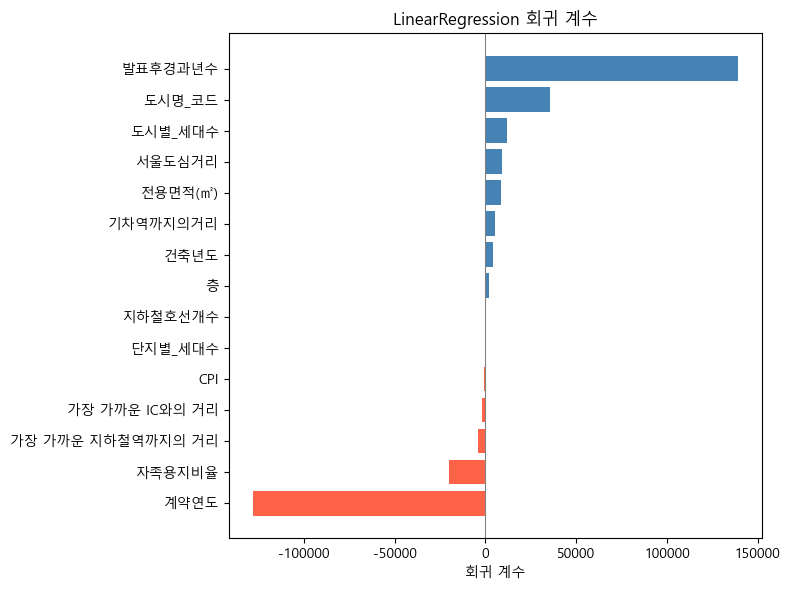

In [25]:
coef_sorted = coefficients.sort_values(by="Coefficient")

plt.figure(figsize=(8, 6))
colors = ["tomato" if v < 0 else "steelblue" for v in coef_sorted["Coefficient"]]
plt.barh(coef_sorted["Feature"], coef_sorted["Coefficient"], color=colors)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("회귀 계수")
plt.title("LinearRegression 회귀 계수")
plt.tight_layout()
plt.show()

---
### **9. 교차 검증 (5-Fold)**

In [26]:
cv_scores = cross_validate(
    model, X_train_scaled, y_train,
    cv=5,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)

print('교차 검증 결과 (R²)')
print(f'  학습 세트 평균: {np.mean(cv_scores["train_score"]):.4f}')
print(f'  검증 세트 평균: {np.mean(cv_scores["test_score"]):.4f}')

교차 검증 결과 (R²)
  학습 세트 평균: 0.7426
  검증 세트 평균: 0.7424


---
### **9. 모델 성능 평가**

In [27]:
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('===== 회귀 성능 평가 결과 =====')
print(f'MAE  (평균 절대 오차):    {mae:,.0f} 만원')
print(f'RMSE (평균 제곱근 오차):  {rmse:,.0f} 만원')
print(f'R²   (결정계수):          {r2:.4f}')

===== 회귀 성능 평가 결과 =====
MAE  (평균 절대 오차):    8,107 만원
RMSE (평균 제곱근 오차):  10,947 만원
R²   (결정계수):          0.7383


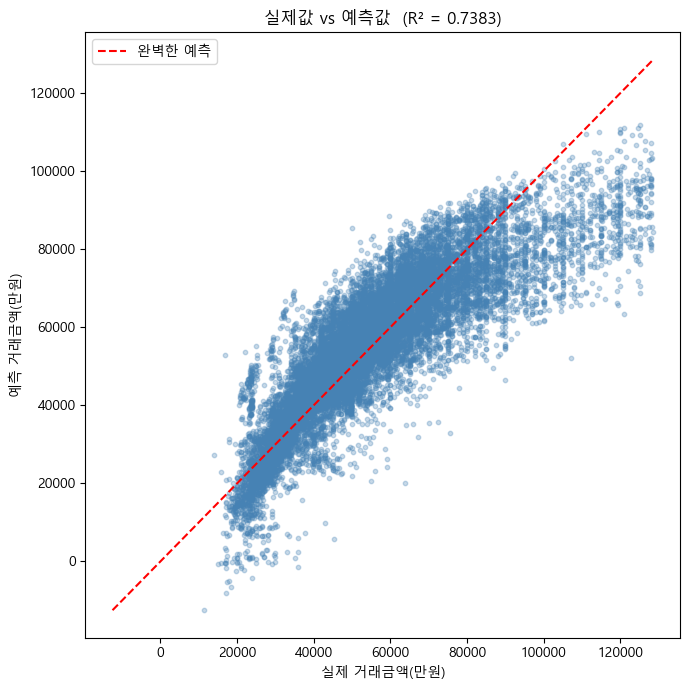

In [28]:
# 실제값 vs 예측값 산점도
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=10)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="완벽한 예측")

plt.xlabel('실제 거래금액(만원)')
plt.ylabel('예측 거래금액(만원)')
plt.title(f'실제값 vs 예측값  (R² = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.show()